# Data reduction to find $I_{real}$

### 1.) Start a Jupyter notebook that will contain all sort of things you will learn in the course of your data analysis. 
Keep here your procedures that you run so that you can quickly re-run them with a few keystrokes. Also keep here anything you’d keep in a paper logbook regarding notes about your reduction. Markdown in your Jupyter notebook will take the place of formal reduction notes. The quality of the this file will make up one component of the grade for this homework.

In [511]:
# import block
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
%matplotlib inline
#from matplotlib import rc

from astropy.visualization import hist
#from astropy.stats import mad_std

#from ccdproc import ImageFileCollection

from matplotlib import rc
import matplotlib as mpl
%matplotlib inline
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from astropy.modeling import fitting
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D
from astropy.nddata import CCDData
import glob
from datetime import datetime
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from astropy.nddata import CCDData
from astropy.stats import sigma_clip

## 2.) Examine the images in DS9 to become familiar with where the overscan region of the chip is (on both sides of the data section; make note of where this is). 
Look at examples of bias images, dark images, and flats so that you can know by inspection what kind of image you are viewing.

In [512]:
data_dir = 'Desktop/Obs_NB/Imaging'

In [513]:
hdu = fits.open('Desktop/Obs_NB/Imaging/a008.fits')
hdr = hdu[0].header
img_flat = hdu[0].data
img_flat.shape

(2048, 2200)

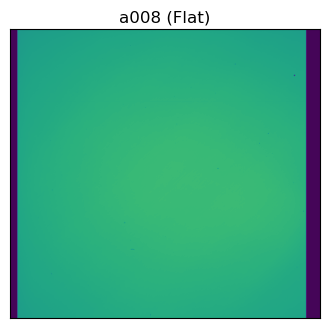

In [514]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_flat) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('a008 (Flat)')
plt.grid(False)
plt.show()

*Black bars seem to be overscan so DS9 can be used to really zero in on the coordinates of those regions. To get an image without the bars we need to use coordinates [1:2048,53:2102]-HH

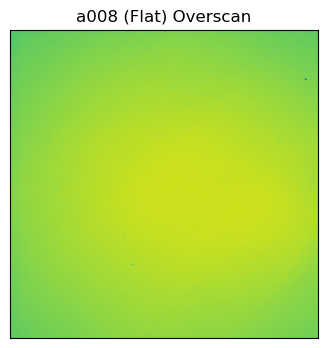

In [515]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_flat[1:2048,54:2101]) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('a008 (Flat) Overscan')
plt.grid(False)
plt.show()

In [516]:
hdu = fits.open('Desktop/Obs_NB/Imaging/a109.fits')
hdr = hdu[0].header
img_bias = hdu[0].data

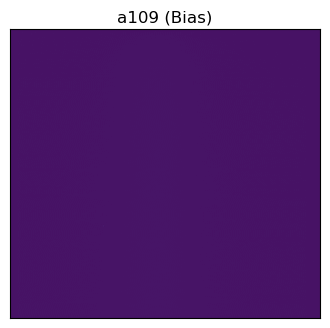

In [517]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_bias) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('a109 (Bias)')
plt.grid(False)
plt.show()

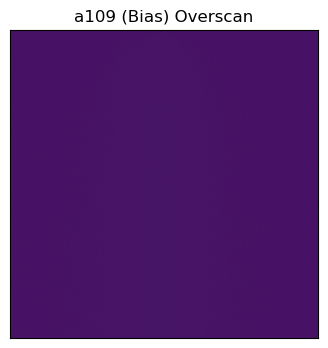

In [518]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_bias[1:2048,54:2101]) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('a109 (Bias) Overscan')
plt.grid(False)
plt.show()

In [519]:
hdu = fits.open('Desktop/Obs_NB/Imaging/d010.fits')
hdr = hdu[0].header
img_dark = hdu[0].data

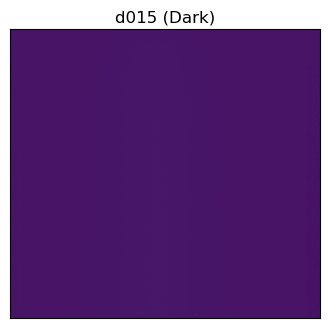

In [520]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_dark) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('d015 (Dark)')
plt.grid(False)
plt.show()

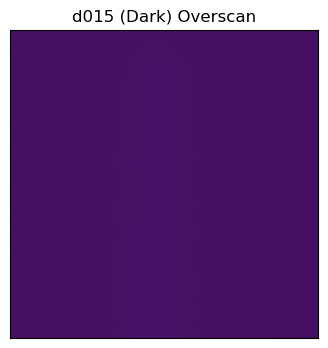

In [521]:
fig = plt.subplots(1,1,figsize=(4,4))
plt.imshow(img_dark[1:2048,54:2101]) #, vmin=min_level, vmax=max_level)
plt.xticks([])
plt.yticks([])
plt.title('d015 (Dark) Overscan')
plt.grid(False)
plt.show()

*I can also make a plot like the one in the CCD reduction guide "1.6 Overscan" https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.html -HH

In [522]:
bias = CCDData.read('Desktop/Obs_NB/Imaging/a109.fits', unit='count')
flat = CCDData.read('Desktop/Obs_NB/Imaging/a008.fits', unit='count')
dark = CCDData.read('Desktop/Obs_NB/Imaging/d010.fits', unit='count')

Text(0.5, 1.0, 'Overscan region, averaged over all rows')

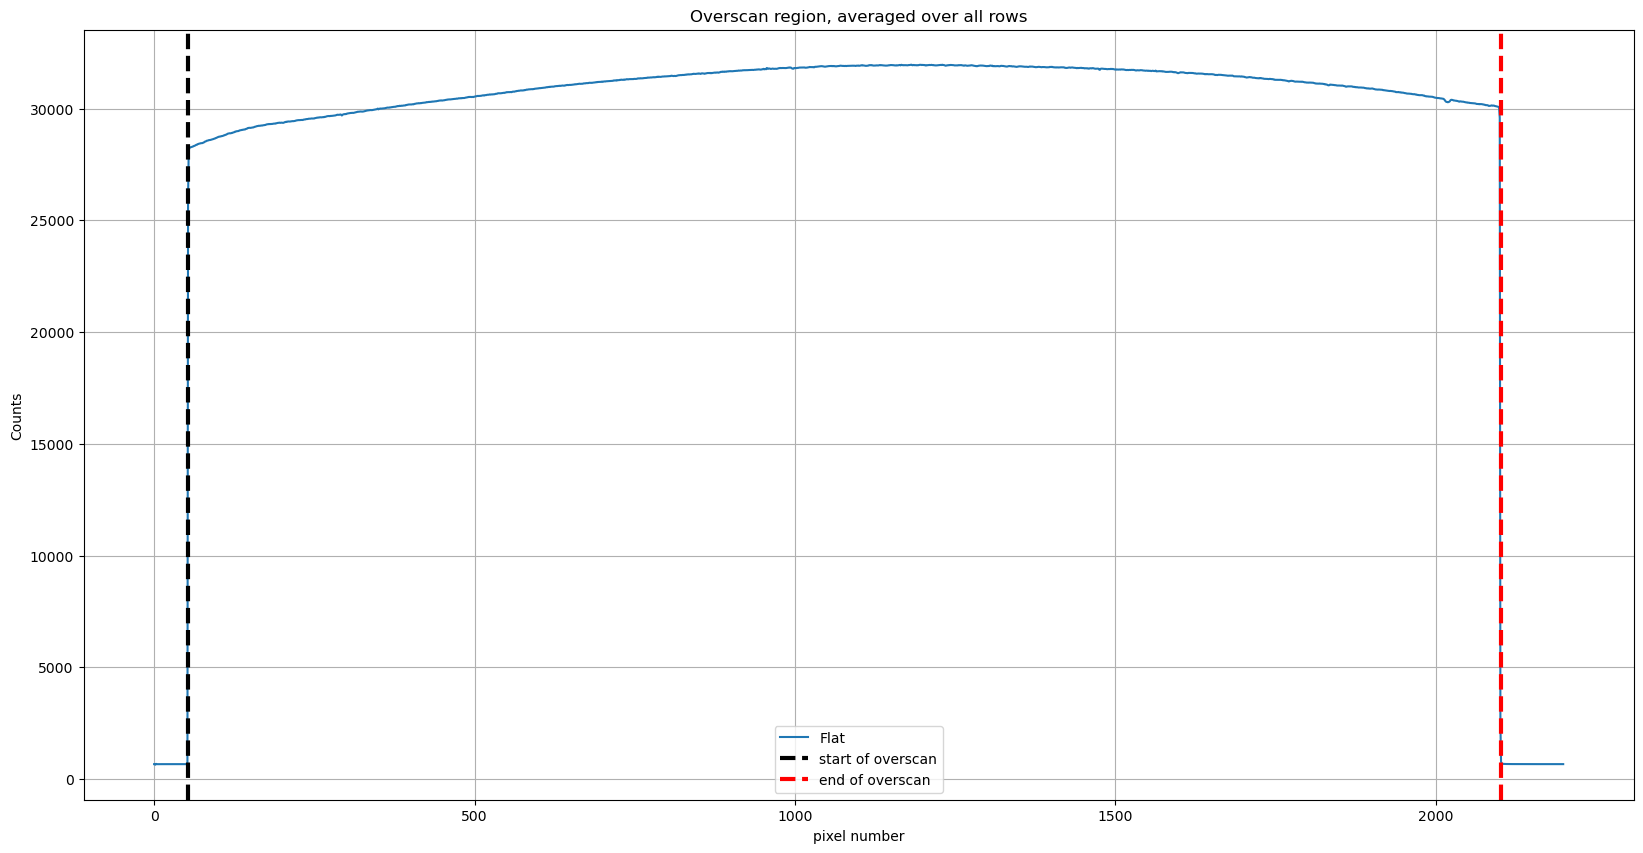

In [523]:
plt.figure(figsize=(20,10))
#plt.plot(bias.data.mean(axis=0), label='Bias')
plt.plot(flat.data.mean(axis=0), label='Flat')
#plt.plot(dark.data.mean(axis=0), label='Dark')
plt.grid()
plt.axvline(x=53, color='black', linewidth=3, linestyle='dashed', label='start of overscan')
plt.axvline(x=2102, color='red', linewidth=3, linestyle='dashed', label='end of overscan')
plt.legend()
plt.xlabel('pixel number')
plt.ylabel('Counts')
plt.title('Overscan region, averaged over all rows')

Text(0.5, 1.0, 'Overscan region, averaged over all rows')

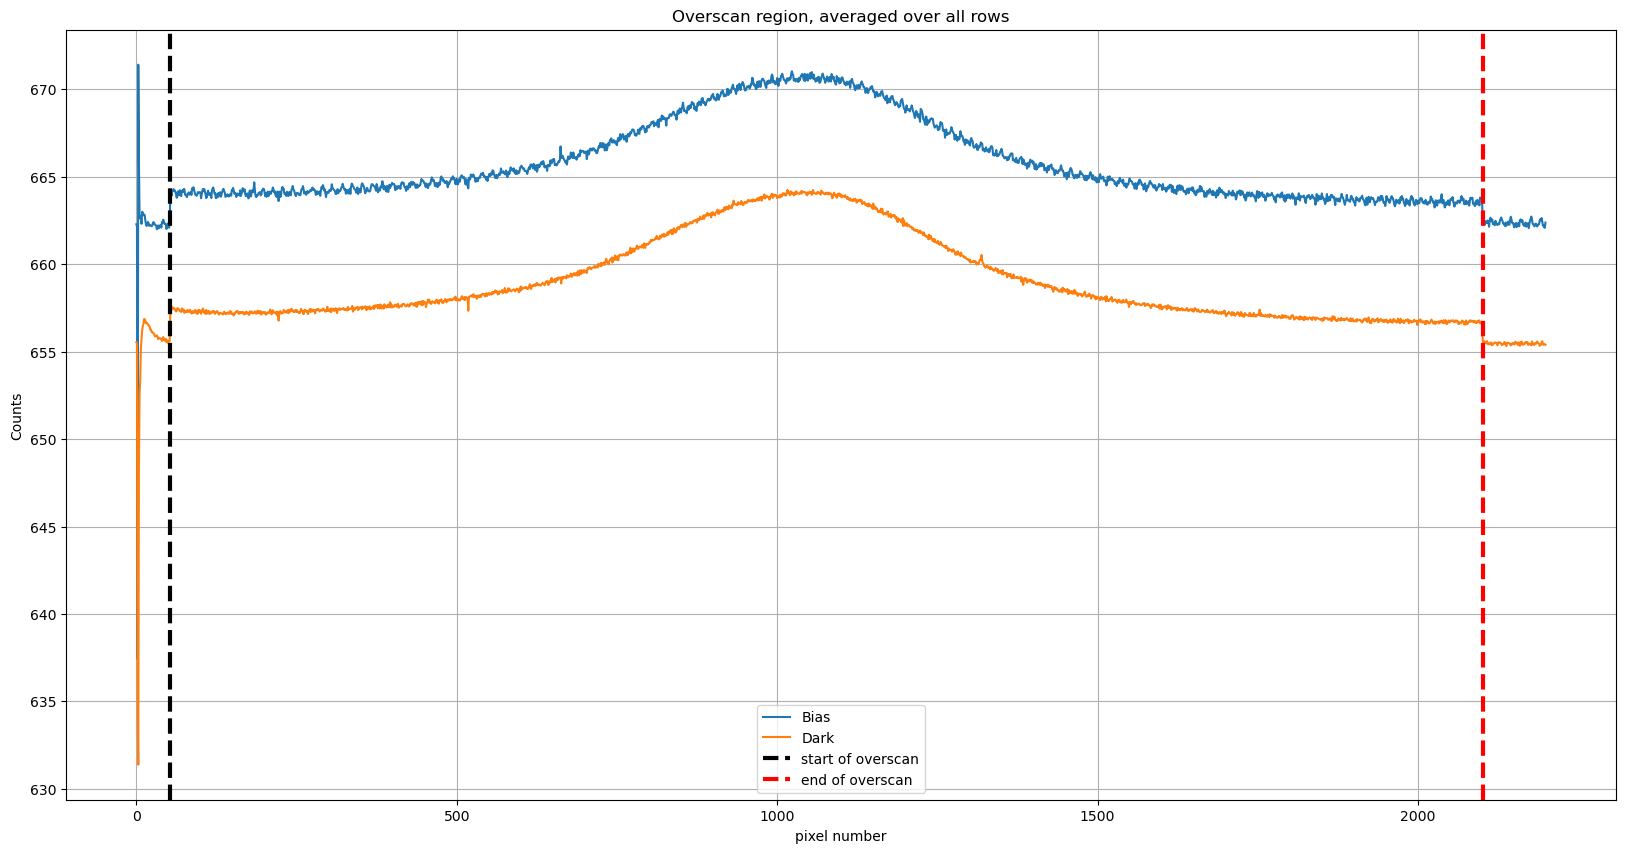

In [524]:
plt.figure(figsize=(20,10))
plt.plot(bias.data.mean(axis=0), label='Bias')
#plt.plot(flat.data.mean(axis=0), label='Flat')
plt.plot(dark.data.mean(axis=0), label='Dark')
plt.grid()
plt.axvline(x=53, color='black', linewidth=3, linestyle='dashed', label='start of overscan')
plt.axvline(x=2102, color='red', linewidth=3, linestyle='dashed', label='end of overscan')
plt.legend()
plt.xlabel('pixel number')
plt.ylabel('Counts')
plt.title('Overscan region, averaged over all rows')

## 3.) Assess the RMS and mean levels of an image. 
Use Python to practice plotting lines and columns of data from one of the bias images.

In [526]:
hdu = fits.open('Desktop/Obs_NB/Imaging/a109.fits')
hdr = hdu[0].header
img_bias = hdu[0].data

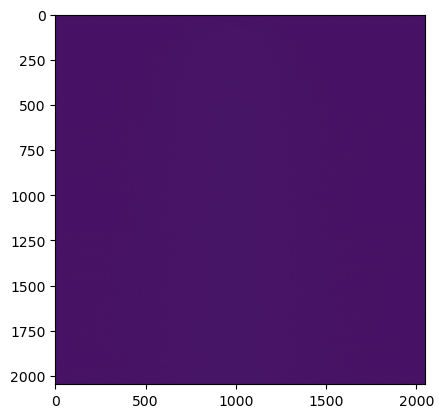

In [642]:
plt.imshow(img_bias[1:2048,54:2101])

We can plot out some slices

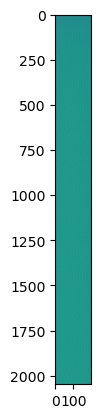

In [528]:
plt.imshow(img_bias[0:2048,1000:1200])

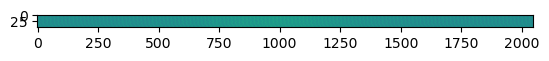

In [529]:
plt.imshow(img_bias[500:550,53:2102])

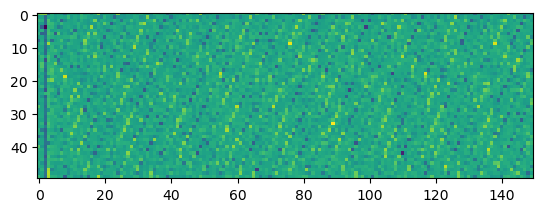

In [530]:
plt.imshow(img_bias[0:50,0:150])

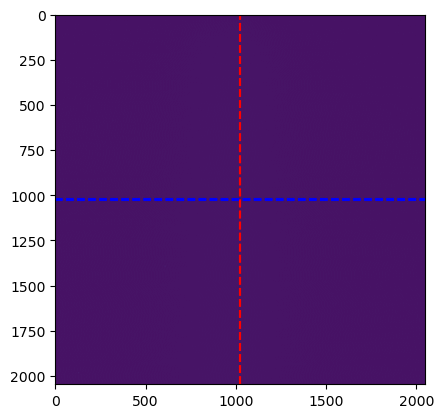

In [531]:
plt.imshow(img_bias[1:2048,54:2101])
plt.axhline(y = 1022, linestyle = '--', c='blue')
plt.axvline(x = 1022, linestyle = '--', c='red')
plt.axhline(y = 1024, linestyle = '--', c='blue')
plt.axvline(x = 1024, linestyle = '--', c='red')

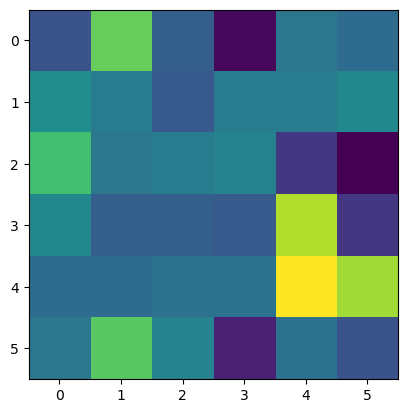

In [532]:
#10x10 center of pixel
#plt.imshow(img_bias[1018:1028,1018:1028])
#6x6
plt.imshow(img_bias[1020:1026,1020:1026])
#4x4
#plt.imshow(img_bias[1021:1025,1021:1025])
#2x2
#plt.imshow(img_bias[1022:1024,1022:1024]) 

In [643]:
# height x width
#width=2200
#height=2048
img_bias[1:2048,54:2101].shape

(2047, 2047)

#### Use Python to compute the mean and RMS of a region near the center of the chip.

In [534]:
# Calculate RMS
center_bias=img_bias[1020:1026,1020:1026]

def RMS(center_bias):
    rms=np.sqrt(np.mean(center_bias**2))
    return rms

In [535]:
RMS(center_bias)

221.71553346073384

In [536]:
# Calculate Mean
np.mean(center_bias)

674.5555555555555

## 5.) Examine the all bias exposures (or overscan regions throughout the night) and quantify how much the bias level changes throughout the night. 

#### Compare the mean level of the biases to the mean levels of the overscan regions from other files throughout the night.

In [537]:
bias=['a093', 'a094', 'a095', 'a096', 'a097', 'a098', 'a099', 'a100', 'a101', 'a102', 'a103','a104','a105','a106', 'a107','a108','a109','a110','a111']

In [538]:
img={}

for r in bias:
    hdu = fits.open(f'Desktop/Obs_NB/Imaging/{r}.fits')
    hdr = hdu[0].header
    img["img" + str(r)]= hdu[0].data

img

{'imga093': array([[687, 690, 686, ..., 659, 663, 658],
        [662, 659, 635, ..., 681, 645, 662],
        [658, 664, 635, ..., 673, 665, 655],
        ...,
        [659, 660, 633, ..., 664, 638, 659],
        [655, 662, 637, ..., 659, 670, 660],
        [670, 667, 639, ..., 644, 655, 668]], dtype=uint16),
 'imga094': array([[693, 680, 688, ..., 655, 666, 656],
        [661, 661, 637, ..., 660, 631, 660],
        [661, 658, 635, ..., 661, 647, 654],
        ...,
        [646, 664, 637, ..., 662, 664, 663],
        [665, 660, 634, ..., 663, 662, 599],
        [651, 662, 639, ..., 664, 657, 667]], dtype=uint16),
 'imga095': array([[686, 692, 687, ..., 634, 658, 663],
        [645, 659, 631, ..., 664, 659, 659],
        [663, 662, 636, ..., 662, 671, 649],
        ...,
        [664, 658, 611, ..., 662, 662, 663],
        [661, 664, 641, ..., 664, 664, 667],
        [645, 635, 632, ..., 663, 664, 661]], dtype=uint16),
 'imga096': array([[682, 681, 687, ..., 674, 636, 654],
        [660, 

In [541]:
# mean level of individual biases
bias_means=[]
for r in img.keys():
    num=img[r]
    num1=np.mean(num)
    bias_means.append(num1)
bias_means

[665.8330812766335,
 665.5039513050426,
 665.5575142045454,
 665.671338112571,
 665.6596943803268,
 665.6369082919034,
 665.590732421875,
 665.5508478338069,
 665.576504350142,
 665.5441748046875,
 665.5616748046875,
 665.5511001864346,
 665.5479110440341,
 665.5881571821733,
 665.5379947176847,
 665.6019511274858,
 665.5959592507103,
 665.6284390536222,
 665.6325306285511]

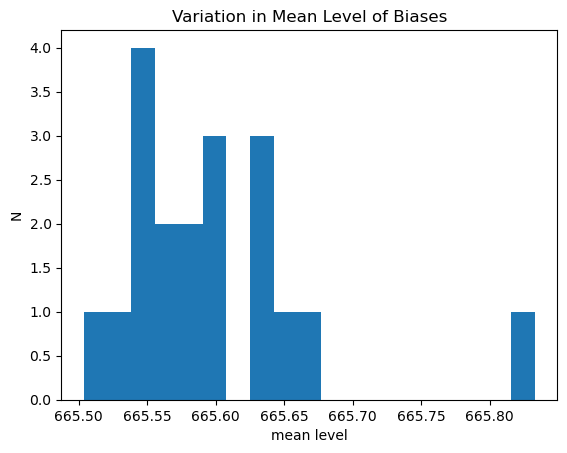

In [542]:
#variation of individual biases 
plt.hist(bias_means, 19, label='Bias Mean Level',)
#plt.hist(mean_img, label='Combined Bias Mean level')
plt.xlabel('mean level')
plt.ylabel('N')
plt.title('Variation in Mean Level of Biases')
plt.show()

In [543]:
print(np.std(bias_means))
print(np.max(bias_means)- np.min(bias_means))

0.07031574977632397
0.32912997159087354


In [544]:
##Now lets look at the overscan region of a science image of NGC6823
overscan_means=[]
for r in range(153,164):
    hdu = fits.open(f'Desktop/Obs_NB/Imaging/a{r}.fits')
    hdr = hdu[0].header
    img_sci= hdu[0].data
    overscan=img_sci[0:2048,2102:2200]
    overscan_means.append(np.mean(overscan))
overscan_means

[660.0242047991071,
 660.1923230229592,
 661.2535524952168,
 661.5864656409439,
 660.4993871572067,
 660.228271484375,
 661.3150759327168,
 661.3996183434311,
 661.4780522560586,
 661.8930414939414,
 663.175950653699]

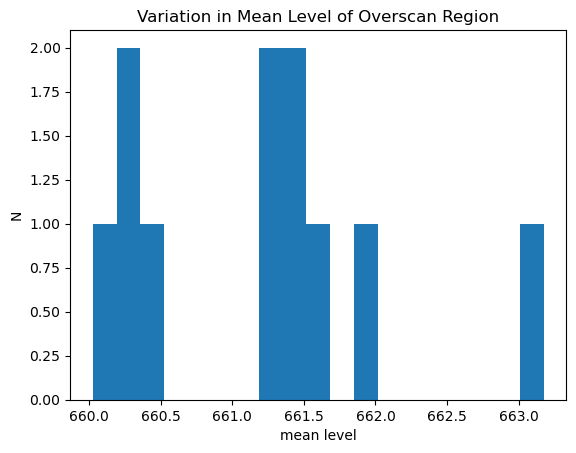

In [546]:
#variation of individual biases 
plt.hist(overscan_means, 19, label='Overscan Mean Level',)
plt.xlabel('mean level')
plt.ylabel('N')
plt.title('Variation in Mean Level of Overscan Region')
plt.show()

In [547]:
print(np.std(overscan_means))
print(np.max(overscan_means)- np.min(overscan_means))

0.8789548747120514
3.1517458545919226


#### How much variation do you find? Make an argument for whether it would be a good or bad idea to combine all of the biases to make a master bias and subtract that from all the images versus using the overscan region of each image as an estimate of the bias level.

*The overscan regions have a higher standard deviation and variation in their mean levels than the biases. On the other hand, the biases' mean levels only differ by decimal points, indicating that it is more stable over time. In this case, using a master bias is probably best. -HH

## 6.) Using CCDPROC.SUBTRACT_OVERSCAN and CCDPROC.TRIM_IMAGE, fit and subtract the overscan region of each image and trim the image to remove the overscan region.

In the overscan fitting, try out ’chebyshev’, ’legendre’, and ’hermite’, and ’polynomial’ of various orders for the fitting function. Qualitatively try to summarize the diﬀerences between the functions (you can also look up and summarize the properties of these types of polynomials, but this is not required). Also try orders 1 through about 8, and make an argument for how large an order is necessary to fit the overscan region.

* Chebyshev1D and Legendre1D are good for fitting smooth overscan structures
* Polynomial1D functions are better at lower orders, as higher orders become unstable
* Chebyshev1D, Hermite1D, and Legendre1D are a orthogonal polynomials
* Hermite polynomials are good for data with gaussian weighted functions
* Higher orders can be an overfit
* Order 1 is good for particularly stable CCDs
* A low order Chebyshev is optimal when fitting the overscan region

In [1040]:
# Lets take an image of PG1633+099
#Chebyshev1D
#adjust degree as necessary 
NGC6823_means_cheb=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], model=Chebyshev1D(degree=7), median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_means_cheb.append(np.mean(trim_sub_NGC))

NGC6823_means_cheb

[48.3590578800192,
 262.9274418447247,
 124.63211750386898,
 25.016696764425554,
 15.59029198601482,
 74.04503284758718,
 142.20403265504132,
 69.58547367029706,
 69.62547538494013,
 18.444364616850887,
 18.562881740829866]

In [1041]:
# Lets take an image of PG1633+099
#Chebyshev1D
NGC6823_nm_cheb=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], median=True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_nm_cheb.append(np.mean(trim_sub_NGC))

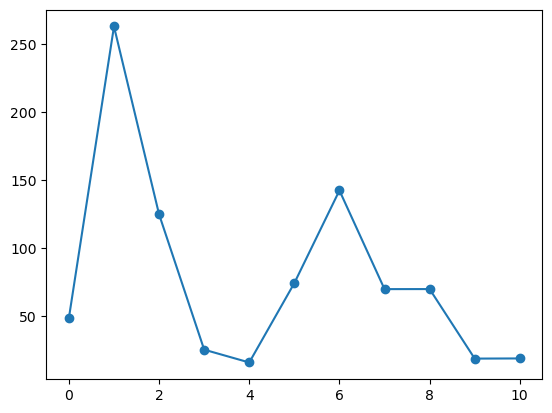

In [1042]:
plt.plot(np.arange(len(NGC6823_means_cheb)), NGC6823_means_cheb)
plt.scatter(np.arange(len(NGC6823_nm_cheb)), NGC6823_nm_cheb)

In [1047]:
#Legendre1D
NGC6823_means_leg=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], model=Legendre1D(degree=6), median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_means_leg.append(np.mean(trim_sub_NGC))

In [1048]:
NGC6823_nm_leg=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_nm_leg.append(np.mean(trim_sub_NGC))

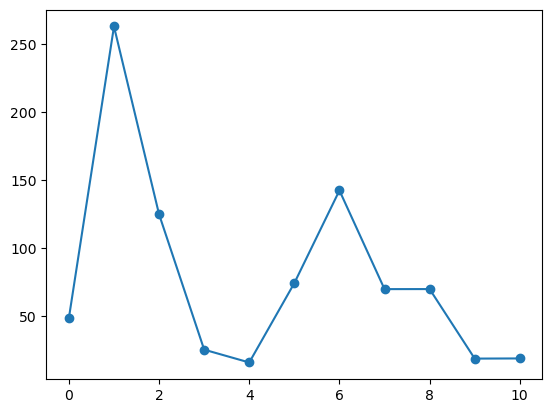

In [1049]:
plt.plot(np.arange(len(NGC6823_means_leg)), NGC6823_means_leg)
plt.scatter(np.arange(len(NGC6823_nm_leg)), NGC6823_nm_leg)

In [1050]:
#Hermite1D
NGC6823_means_herm=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], model=Hermite1D(degree=5), median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_means_herm.append(np.mean(trim_sub_NGC))

In [1051]:
NGC6823_nm_herm=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_nm_herm.append(np.mean(trim_sub_NGC))

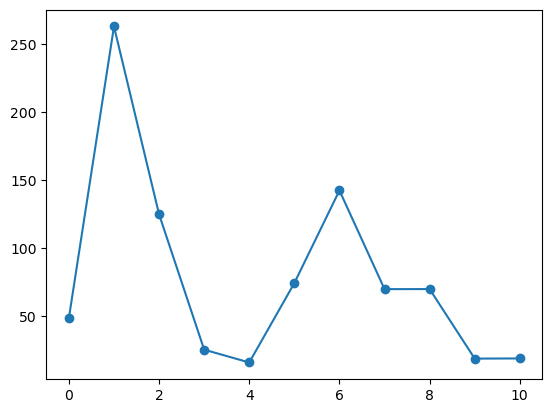

In [1052]:
plt.plot(np.arange(len(NGC6823_means_herm)), NGC6823_means_herm)
plt.scatter(np.arange(len(NGC6823_nm_herm)), NGC6823_means_herm)

In [1056]:
#Polynomial1D
NGC6823_means_poly=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], model=Polynomial1D(degree=3), median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_means_poly.append(np.mean(trim_sub_NGC))

In [1058]:
NGC6823_nm_poly=[]
for r in range(153,164):
    NGC6823=CCDData.read(f'Desktop/Obs_NB/Imaging/a{r}.fits', unit='adu')
    overscan_sub_NGC=ccdp.subtract_overscan(NGC6823, overscan=NGC6823[0:2048,2102:2200], median= True)
    trim_sub_NGC=ccdp.trim_image(overscan_sub_NGC, fits_section='[1:2048,54:2101]')
    NGC6823_nm_poly.append(np.mean(trim_sub_NGC))

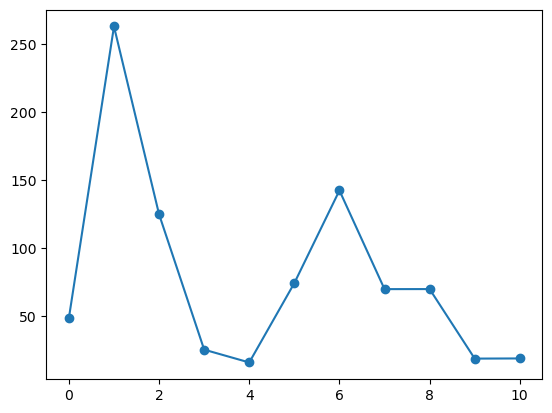

In [1059]:
plt.plot(np.arange(len(NGC6823_means_poly)), NGC6823_means_poly)
plt.scatter(np.arange(len(NGC6823_nm_poly)), NGC6823_nm_poly)

## 7.) Combine the bias frames into a master bias frame using CCDPROC.COMBINE. 
By visual inspection or using image statistics, decide whether it is appropriate to combine all your bias exposures to make 1 master bias, or whether you need to restrict the input frames because of variations among your bias frames. 

Are there trends in your sequence of bias frames? Does either the level, or the pattern of the bias change throughout the night? 

If so, by how much? 

In [548]:
bias=['a093', 'a094', 'a095', 'a096', 'a097', 'a098', 'a099', 'a100', 'a101', 'a102', 'a103','a104','a105','a106', 'a107','a108','a109','a110','a111']

In [549]:
bias_list=[]
for r in bias:
    biases=CCDData.read(f'Desktop/Obs_NB/Imaging/{r}.fits', unit='adu')
    bias_list.append(biases)

In [550]:
master_bias=ccdp.combine(bias_list, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)

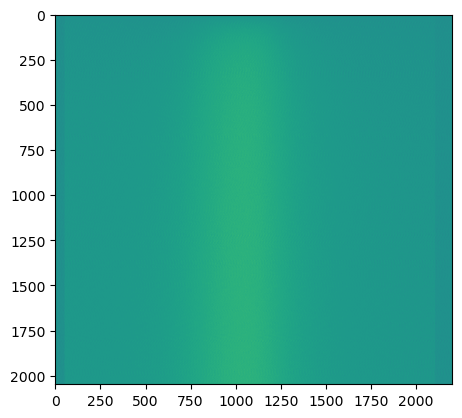

In [551]:
 plt.imshow(master_bias)

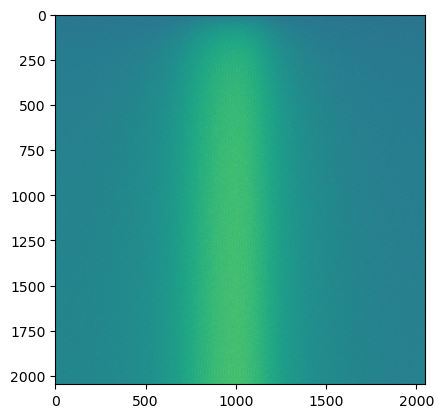

In [552]:
 plt.imshow(master_bias[1:2048,54:2101])

In [637]:
#Using CCD reduction guide "2.2 Calibrating Bias Images" 
bias_overscan_subtracted = ccdp.subtract_overscan(master_bias, overscan=master_bias[0:2048,2102:2200], median=True)

In [554]:
trimmed_bias = ccdp.trim_image(bias_overscan_subtracted[1:2048,54:2101])

<function matplotlib.pyplot.show(close=None, block=None)>

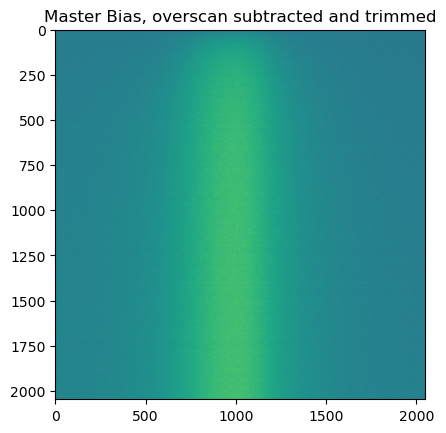

In [555]:
plt.imshow(trimmed_bias.data)
plt.title('Master Bias, overscan subtracted and trimmed')
plt.show

In [727]:
# mean level of individual biases
bias_median=[]
bias_std=[]
bias_mean=[]
bias_collective=[]
for r in bias:
    biases_open=CCDData.read(f'Desktop/Obs_NB/Imaging/{r}.fits', unit='adu')
    substract_overscan_biases=ccdp.subtract_overscan(biases_open, overscan=biases_open[0:2048,2102:2200], median=True)
    trimmed_bias_1=ccdp.trim_image(substract_overscan_biases[1:2048,54:2101])
    num1=np.median(trimmed_bias_1)
    num2=np.std(trimmed_bias_1)
    num3=np.mean(trimmed_bias_1)
    bias_collective.append(trimmed_bias_1)
    bias_median.append(num1)
    bias_std.append(num2)
    bias_mean.append(num3)

In [717]:
bias_mean

[3.3779132496732265,
 3.377387619567425,
 3.403279406826724,
 3.3802853270564786,
 3.3747414508440987,
 3.3921912964245937,
 3.3907994804077792,
 3.3823621924347926,
 3.392989824612567,
 3.3743318054063653,
 3.396659927941542,
 3.4052270423742588,
 3.3878369790146508,
 3.387739012540902,
 3.412137556861722,
 3.3942062317177975,
 3.3977084436599703,
 3.3889591187456283,
 3.3980494767683425]

In [639]:
bias_std

[9.56290872825828,
 8.876713235175519,
 8.894416154185405,
 8.884324228449188,
 9.13847353815288,
 8.883969272993564,
 8.876275054389737,
 8.907103977702844,
 8.876875104612127,
 9.037070451122295,
 9.198127186091467,
 8.871423564634526,
 8.869859816948148,
 9.2373411686367,
 8.95473416143227,
 8.933369150807515,
 8.906088990488486,
 8.90237908197303,
 8.868151083228605]

In [641]:
bias_median

[3.3779132496732265,
 3.377387619567425,
 3.403279406826724,
 3.3802853270564786,
 3.3747414508440987,
 3.3921912964245937,
 3.3907994804077792,
 3.3823621924347926,
 3.392989824612567,
 3.3743318054063653,
 3.396659927941542,
 3.4052270423742588,
 3.3878369790146508,
 3.387739012540902,
 3.412137556861722,
 3.3942062317177975,
 3.3977084436599703,
 3.3889591187456283,
 3.3980494767683425]

*There aren't any notable outliers in the biases' data, they all seem to follow a constistent trend in terms of mean and median -HH

#### How much noise would you be adding to your data if you decide to do a bias subtraction in addition to your overscan subtraction. 
Do the subtraction of your master bias from all other science frames if you can justify that it is warranted.

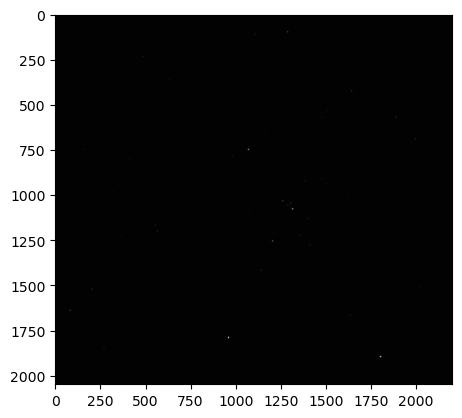

In [796]:
#original image
ngc_153=CCDData.read('Desktop/Obs_NB/Imaging/a153.fits', unit='adu')
plt.imshow(ngc_153, cmap='gray')

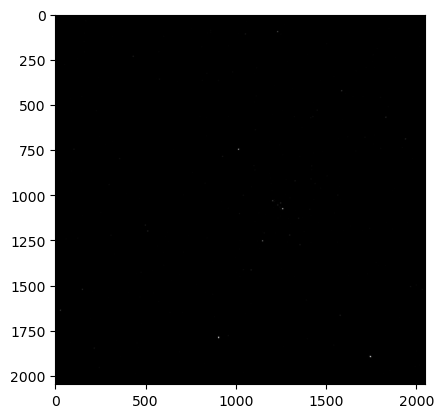

In [728]:
#Overscan subtracted image
substract_overscan_ngc_153=ccdp.subtract_overscan(ngc_153, overscan=ngc_153[0:2048,2102:2200], median=True)
trimmed_overscan_ngc_153=ccdp.trim_image(substract_overscan_ngc_153[1:2048,54:2101])
plt.imshow(trimmed_overscan_ngc_153, cmap='gray')

In [729]:
#Bias subtracted
combined_bias_col=ccdp.combine(bias_collective, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)

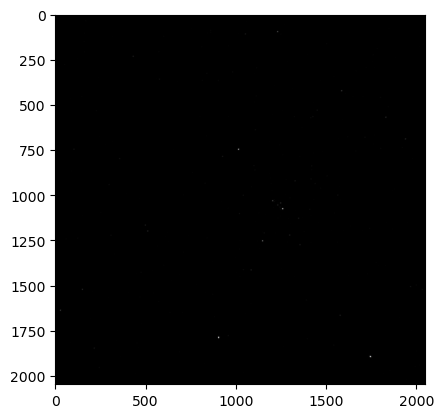

In [741]:
bias_subtracted_ngc_153=ccdp.subtract_bias(trimmed_overscan_ngc_153, combined_bias_col)
plt.imshow(bias_subtracted_ngc_153, cmap='gray')

*We can look to Howell Ch. 4.3 -HH

$$Gain=\frac{(F_1+F_2)-(B_1+B_2)}{\sigma_{F1-F2}^2-\sigma_{B1-B2}^2} $$

In [929]:
flat_collective_V=[]
for f in range(44,50):
    open_f=CCDData.read(f'Desktop/Obs_NB/reduced/otz_flat/a0{f}otz.fits')   
    flat_collective_V.append(open_f)

In [934]:
f1=np.mean(flat_collective_V[0])
f2=np.mean(flat_collective_V[-1])

In [935]:
#biases
bias=['a093', 'a094', 'a095', 'a096', 'a097', 'a098', 'a099', 'a100', 'a101', 'a102', 'a103','a104','a105','a106', 'a107','a108','a109','a110','a111']
biasd=[]
for b in bias:
    b_open=CCDData.read(f'Desktop/Obs_NB/reduced/ot_bias/{b}ot.fits')
    biasd.append(b_open)

In [936]:
b1=np.mean(biasd[0])
b2=np.mean(biasd[-1])

In [945]:
def gain(b1, b2, f1, f2):
    top=(f1+f2)-(b1+b2)
    f_dif_rms=np.sqrt(np.mean((f1-f2)**2))
    b_dif_rms=np.sqrt(np.mean((b1-b2)**2))
    bottom=(f_dif_rms)**2-(b_dif_rms)**2
    g=top/bottom
    return g

gain(b1, b2, f1, f2)

0.000472917391032621

$$Read noise=\frac{\sigma_{B1-B2}*Gain}{\sqrt{2}} $$

In [947]:
b_dif_rms=np.sqrt(np.mean((b1-b2)**2))

read_noise=(b_dif_rms*gain(b1, b2, f1, f2))/np.sqrt(2)
read_noise

6.7336166449168454e-06

*This indicates that the master bias does add some noise -HH

## 8.) Now examine the ‘dark’ images quantitatively and estimate the range of dark current (electrons per pixel per second) you see in the darks. 
WIRO Prime’s gain is 2.5 e−/ADU. Use Python to inspect the header and see the exposure time in each of the darks. Pixel values will vary! Be careful to avoid being fooled by cosmic rays, which will appear as large bright spots usually spread over a few pixels, whereas high dark current is usually isolated to just individual pixels.

In [908]:
from ccdproc import ImageFileCollection
imgs = ImageFileCollection(data_dir,glob_include='d0??.fits',glob_exclude='*ot*.fits') # exclude otz files in case of rerun
imgs.summary['exptime'] 

2
2
2
2
2
5
5
5
5
5
300


In [979]:
bias=['a093', 'a094', 'a095', 'a096', 'a097', 'a098', 'a099', 'a100', 'a101', 'a102', 'a103','a104','a105','a106', 'a107','a108','a109','a110','a111']
biasd=[]
for b in bias:
    b_open=CCDData.read(f'Desktop/Obs_NB/reduced/ot_bias/{b}ot.fits')
    biasd.append(b_open)
    
pro_bias=ccdp.combine(biasd, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)
pro_bias.data

array([[-1.73684211, -0.78947368,  1.05263158, ...,  2.16666667,
        -3.15789474,  1.63157895],
       [ 1.41666667, -0.19444444,  0.94444444, ...,  4.34210526,
        -0.55263158,  0.18421053],
       [-0.41666667,  1.5       ,  1.75      , ...,  0.86842105,
        -1.44736842,  1.76315789],
       ...,
       [-0.55263158,  3.60526316,  1.39473684, ...,  3.86842105,
         1.39473684,  1.28947368],
       [ 2.30555556,  2.71052632,  2.47222222, ...,  0.02631579,
         3.39473684,  0.80555556],
       [ 4.42105263,  1.55555556,  2.        , ...,  2.36842105,
         1.68421053,  1.94736842]])

*Use equation discussed in the CCD reduction guide "3.2. Real dark current: noise and other artifacts"-HH

$$D_{current}=\frac{(n_{dark}-n_{bias})*gain}{exposure time} $$

In [984]:
gain=2.5 #e−/ADU
D_current=[]
drk=glob.glob('Desktop/Obs_NB/reduced/ot_dark/d???ot.fits')
for d in drk:
    open_drk=CCDData.read(f'{d}')
    bias_subtracted_dark=ccdp.subtract_bias(open_drk, pro_bias)
    top=np.median(bias_subtracted_dark)*gain
    bottom=open_drk[0].header['exptime']
    current=top/bottom
    D_current.append(current)

In [966]:
#I'm not sure if there should be negative values here, I could only get the code to the select median value after bias subtraction
D_current

[0.10416666666666685,
 -0.00021929824561403506,
 -0.00023148148148148065,
 0.09868421052631582,
 0.09868421052631582,
 0.03947368421052655,
 0.00043859649122806785,
 0.026315789473684292,
 0.10416666666666685,
 0.03947368421052633,
 0.0,
 0.06578947368421073,
 0.02777777777777779,
 -0.00043859649122806785,
 0.03947368421052633]

In [917]:
np.max(D_current)

0.10416666666666685

In [918]:
np.min(D_current)

-0.00043859649122806785

*the range of dark curent is -0.00043859649122806785 to 0.10416666666666685 -HH

## 9.) Use CCDPROC.COMBINE to combine darks together to make a master dark. You will need to play with diﬀerent combination parameters to see which one does the best job of eliminating cosmic rays. At a minimum, do


In [584]:
darks=glob.glob('Desktop/Obs_NB/Imaging/d0??.fits')

In [616]:
dark_list=[]
for d in darks:
    open_dark=CCDData.read(f'{d}', unit='adu')
    substract_overscan_dark=ccdp.subtract_overscan(open_dark, overscan=open_dark[0:2048,2102:2200], median=True)
    trimmed_dark=ccdp.trim_image(substract_overscan_dark[1:2048,54:2101])
    dark_list.append(trimmed_dark)

#### A straight average of all dark frames.

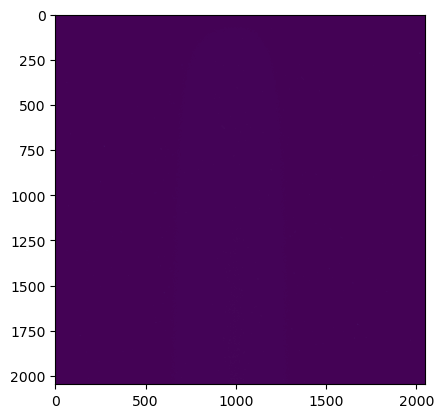

In [625]:
master_dark_avg=ccdp.combine(dark_list, method='average', sigma_clip=False)

plt.imshow(master_dark_avg)

#### A straight median of all dark frames.

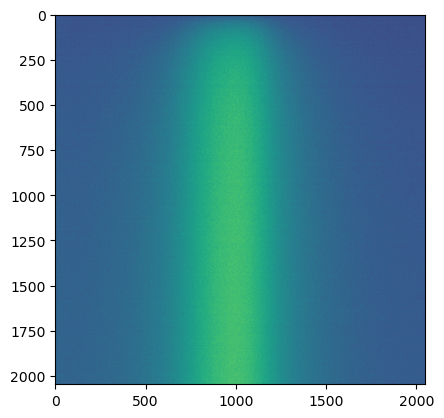

In [618]:
master_dark_med=ccdp.combine(dark_list, method='median', sigma_clip=False)

plt.imshow(master_dark_med)

#### An average where outlier pixels are rejected if they are more than 3σ away from the mean.

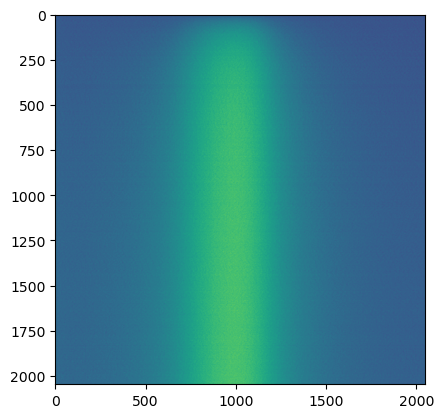

In [619]:
master_dark_avg_sigclip=ccdp.combine(dark_list, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)

plt.imshow(master_dark_avg_sigclip)

#### A median where outlier pixels are rejected if they are more than 3σ away from the mean.

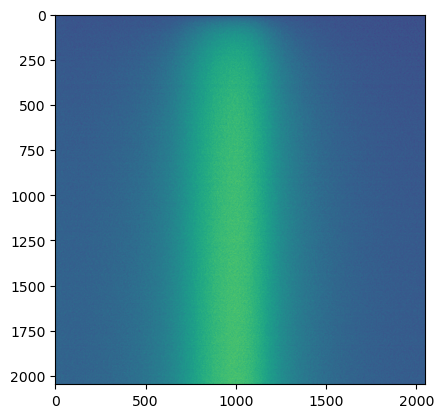

In [620]:
master_dark_med_sigclip=ccdp.combine(dark_list, method='median', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)

plt.imshow(master_dark_med_sigclip)

#### Use the resulting RMS in the master image as an indicator of which combination procedure is best. 

How many times larger is the typical dark current than the noise (σ) in the master image?

In [626]:
#just average
RMS(master_dark_avg.data)

4.631728092765217

In [627]:
#just median
RMS(master_dark_med.data)

4.5105764950785945

In [628]:
#avg and sigclip
RMS(master_dark_avg_sigclip.data)

4.451814856362557

In [629]:
#med and sigclip
RMS(master_dark_med_sigclip.data)

4.511439428189293

*Lower RMS indicates a cleaner master so an average where outlier pixels are rejected if they are more than 3σ away from the mean is optimal -HH

#### Compare your master dark to your master bias to estimate the significance of the highest dark count pixels. 

*Looking at CCD Data Reduction Guide "6.1. Identifying hot pixels" -HH

$$D_{current}=\frac{dark counts*gain}{exposure time} $$

In [991]:
dark_counts=master_dark_avg_sigclip.data-pro_bias.data

In [996]:
#highest dark count
np.max(dark_counts)

14.894736842105264

In [997]:
#z-score
standard=(np.max(dark_counts)-np.mean(dark_counts))/np.std(dark_counts)

In [998]:
standard

6.890544003197056

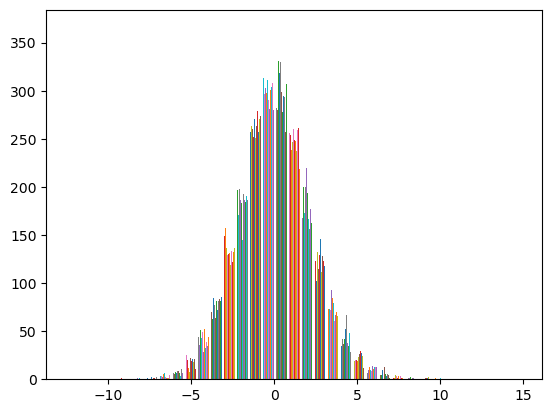

In [1003]:
plt.hist(dark_counts, 35)
plt.show()

In [1014]:
np.mean(dark_counts)+(np.std(dark_counts)*3)

6.504706282359326

*The highest dark count pixel is $3\sigma$ from the mean in a normal distribution, ~0.3% of data falls within this range

#### How many times larger is the typical dark current than the noise (σ) in the master image?

*Looking at CCD Data Reduction Guide "3.2. Real dark current: noise and other artifacts" 

In [1065]:
#Noise of combined image is proportional to 1/sqrt(N)
noise=1/np.sqrt(15)
noise

0.2581988897471611

In [1068]:
np.mean(D_current)

0.04290367121507479

The typical dark current differs by a factor of 1/6, I mentioned earlier that the dark frame values were coming out negative which is why the dark current is lower that expected.

## The aim of this assignment is to...
characterize and subtract the overscan region, trim the frames so that a 2048x2048 data section remains, create a master bias, subtract it from all of the frames that you will need, and save the processed images with “otz” added to their filenames to indicate that these steps have been conducted. Your submission should be a Jupyter notebook that executes the tasks above for at least the following frames: biases, flats in all bands, darks, science frames for PG1633+099 and NGC6823.

Frames that you will need:

Biases (a093-a111)

Flats in all bands (a005-a062) *omit 56 and 63

Darks (d01-d15)

PG1633+099 (64-92)

NGC6823

#### characterize and subtract the overscan region and trim the frames so that a 2048x2048 data section remains
need to save these files as otz in new folder: overscan subtracted=o, trimmed=t, bias corredted=z, flat field corrected=f, dark corrected=d

In [847]:
import os

In [807]:
overscan_region='[0:2048,2102:2200]'
trim='[1:2048,54:2101]'
#trims down to 2047x2047, I hope thats okay

In [892]:
#biases
bias=['a093', 'a094', 'a095', 'a096', 'a097', 'a098', 'a099', 'a100', 'a101', 'a102', 'a103','a104','a105','a106', 'a107','a108','a109','a110','a111']
bias_collective=[]
for b in bias:
    biases_open=CCDData.read(f'Desktop/Obs_NB/Imaging/{b}.fits', unit='adu')
    substract_overscan_biases=ccdp.subtract_overscan(biases_open, overscan=biases_open[0:2048,2102:2200], median=True)
    trimmed_bias=ccdp.trim_image(substract_overscan_biases[1:2048,54:2101])
    output_path= os.path.join('Desktop/Obs_NB/reduced/ot_bias', f'{b}ot.fits')
    trimmed_bias.write(output_path, overwrite=True)
    bias_collective.append(trimmed_bias)

In [893]:
#darks
darks=glob.glob('Desktop/Obs_NB/Imaging/d0??.fits')
darks_collective=[]
for d in darks:
    open_dark=CCDData.read(f'{d}', unit='adu')
    substract_overscan_dark=ccdp.subtract_overscan(open_dark, overscan=open_dark[0:2048,2102:2200], median=True)
    trimmed_dark=ccdp.trim_image(substract_overscan_dark[1:2048,54:2101])
    base_name=os.path.basename(d)
    file_name=os.path.splitext(base_name)[0]
    output_path= os.path.join('Desktop/Obs_NB/reduced/ot_dark', f'{file_name}ot.fits')
    trimmed_dark.write(output_path, overwrite=True)
    darks_collective.append(trimmed_dark)

In [894]:
#flats
#flat 56 and 63 are labeled as 'bad' so I'll omit those 
flats_collective=[]
for f in range(5,63):
    if f<10:
        f=str(0)+str(f)
    if f == 56:
        continue
    open_flats=CCDData.read(f'Desktop/Obs_NB/Imaging/a0{f}.fits', unit='adu')
    substract_overscan_flats=ccdp.subtract_overscan(open_flats, overscan=open_flats[0:2048,2102:2200], median=True)
    trimmed_flats=ccdp.trim_image(substract_overscan_flats[1:2048,54:2101])
    output_path= os.path.join('Desktop/Obs_NB/reduced/ot_flat', f'a0{f}ot.fits')
    trimmed_flats.write(output_path, overwrite=True)
    flats_collective.append(trimmed_flats)

In [895]:
#PG1633+099
PG1633_collective=[]
for p in range(64,93):
    open_PG1633=CCDData.read(f'Desktop/Obs_NB/Imaging/a0{p}.fits', unit='adu')
    substract_overscan_PG1633=ccdp.subtract_overscan(open_PG1633, overscan=open_PG1633[0:2048,2102:2200], median=True)
    trimmed_PG1633=ccdp.trim_image(substract_overscan_PG1633[1:2048,54:2101])
    output_path= os.path.join('Desktop/Obs_NB/reduced/ot_PG1633+099', f'a0{p}ot.fits')
    trimmed_PG1633.write(output_path, overwrite=True)
    PG1633_collective.append(trimmed_PG1633)    

In [896]:
#NGC6823
NGC6823_collective=[]
for n in range(153, 164):
    open_NGC=CCDData.read(f'Desktop/Obs_NB/Imaging/a{n}.fits', unit='adu')
    substract_overscan_NGC=ccdp.subtract_overscan(open_NGC, overscan=open_NGC[0:2048,2102:2200], median=True)
    trimmed_NGC=ccdp.trim_image(substract_overscan_NGC[1:2048,54:2101])
    output_path= os.path.join('Desktop/Obs_NB/reduced/ot_NGC6823', f'a{n}ot.fits')
    trimmed_NGC.write(output_path, overwrite=True)    
    NGC6823_collective.append(trimmed_NGC)    

#### Create a master bias

In [897]:
bias_master=ccdp.combine(bias_collective, method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)

#### Subtract it from all of the frames that you will need, and save the processed images with “otz” added to their filenames to indicate that these steps have been conducted.

In [898]:
flat_collective_bias=[]
fltt=glob.glob('Desktop/Obs_NB/reduced/ot_flat/a???ot.fits')
for f in fltt:
    open_fltt=CCDData.read(f'{f}')
    bias_subtracted_flat=ccdp.subtract_bias(open_fltt, bias_master)
    base_name=os.path.basename(f)
    file_name=os.path.splitext(base_name)[0]    
    output_path= os.path.join('Desktop/Obs_NB/reduced/otz_flat', f'{file_name}z.fits')
    bias_subtracted_flat.write(output_path, overwrite=True)    
    flat_collective_bias.append(bias_subtracted_flat)

In [963]:
darks_collective_bias=[]
drk=glob.glob('Desktop/Obs_NB/reduced/ot_dark/d???ot.fits')
for d in drk:
    open_drk=CCDData.read(f'{d}')
    bias_subtracted_dark=ccdp.subtract_bias(open_drk, bias_master)
    base_name=os.path.basename(d)
    file_name=os.path.splitext(base_name)[0]    
    output_path= os.path.join('Desktop/Obs_NB/reduced/otz_dark', f'{file_name}z.fits')
    bias_subtracted_dark.write(output_path, overwrite=True) 
    darks_collective_bias.append(bias_subtracted_dark)